# **Prediksi Viralitas Konten TikTok Menggunakan Multi Layer Perceptron dan Support Vector Machine Berdasarkan Data Engagement Media Sosial**

# **PROJECT AKHIR PEMBELAJARAN MESIN DASAR KELOMPOK 1**

Nama Anggota Kelompok:
1. Yanaka Sofia Pardede (24031554065)
2. Ayu Wulan Anggraeni Putri (24031554177)
3. Annisa Ramadhani (24031554206)

Kelas 2024B

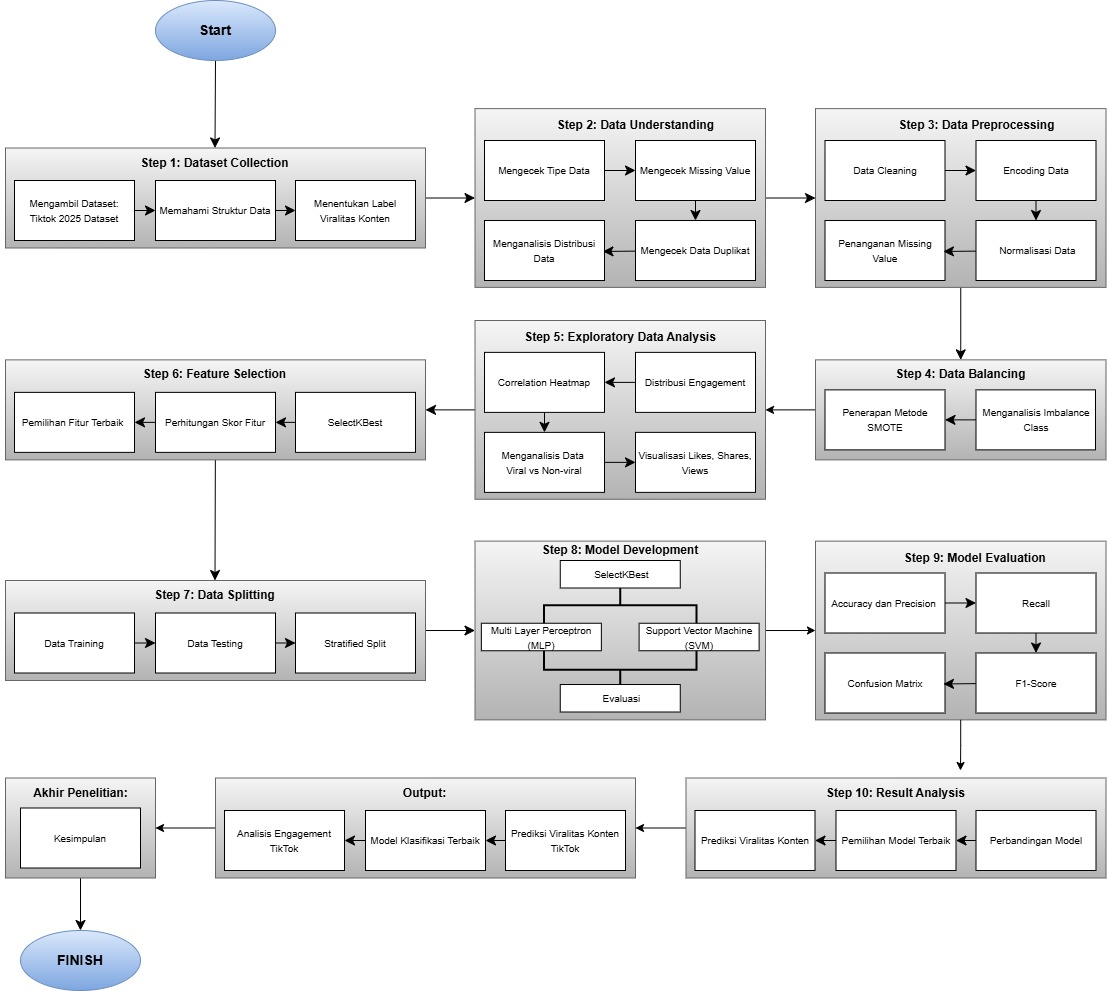

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

## **Step 1: Dataset Collection**

### **Menghubungkan Ke Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Load Dataset**

In [ ]:
path = "/content/drive/Shareddrives/PROJECT PMD KEL 1/tiktok_merged_data_deduplicated.csv"
df = pd.read_csv(path)

print("Dataset berhasil dimuat")
df.head()

Dataset berhasil dimuat


,video_id,author,description,likes,comments,shares,plays,hashtags,music,create_time,video_url,fetch_time,views,posted_time
0,7506183500660313390,dalebrisby90,"That sounds like JB, ima go with TRUTH! 🤔🤣 #ro...",44800,125,1863,686000.0,"rodeotime, dalebrisby, jbmauney",original sound,2025-05-19 15:45:53,https://www.tiktok.com/@dalebrisby90/video/750...,NaN,NaN,NaN
1,7507316543605280030,jessicafloriolli,thanks for sticking around @Alonzofloriolli,285700,290,963,1200000.0,NaN,ECE Marketing Airball,2025-05-22 17:02:36,https://www.tiktok.com/@jessicafloriolli/video...,NaN,NaN,NaN
2,7507286333505719582,ay_2fya,#publicinterview #fyp #rizz,38000,65,496,416100.0,"publicinterview, fyp, rizz",original sound,2025-05-22 15:05:21,https://www.tiktok.com/@ay_2fya/video/75072863...,NaN,NaN,NaN
3,7506662216574209310,abell1823,Boat days hit different ✨,87200,259,23600,725800.0,NaN,If You Were Mine,2025-05-20 22:43:34,https://www.tiktok.com/@abell1823/video/750666...,NaN,NaN,NaN
4,7506628206280363310,jordanmarielynnxoxo,a lululemonnnn. #prettygirl #foryoupage #trend...,77600,724,1196,362100.0,"prettygirl, foryoupage, trending, likes",What Da Fuk,2025-05-20 20:32:12,https://www.tiktok.com/@jordanmarielynnxoxo/vi...,NaN,NaN,NaN


### **Memahami Struktur Data**

In [ ]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

Jumlah Baris dan Kolom:
(7225, 14)


## **Step 2: Data Understanding**

### **Mengecek Tipe Data**

In [ ]:
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7225 entries, 0 to 7224
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   video_id     7225 non-null   int64  
 1   author       7225 non-null   object 
 2   description  6533 non-null   object 
 3   likes        7225 non-null   int64  
 4   comments     7225 non-null   int64  
 5   shares       7225 non-null   int64  
 6   plays        7218 non-null   float64
 7   hashtags     5150 non-null   object 
 8   music        7225 non-null   object 
 9   create_time  7218 non-null   object 
 10  video_url    7225 non-null   object 
 11  fetch_time   7 non-null      object 
 12  views        7 non-null      float64
 13  posted_time  7 non-null      object 
dtypes: float64(2), int64(4), object(8)
memory usage: 790.4+ KB


### **Mengecek Missing Value**

In [ ]:
print("\nMissing Value:")
print(df.isnull().sum())


Missing Value:
video_id          0
author            0
description     692
likes             0
comments          0
shares            0
plays             7
hashtags       2075
music             0
create_time       7
video_url         0
fetch_time     7218
views          7218
posted_time    7218
dtype: int64


### **Mengecek Data Duplikat**

In [ ]:
print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

Jumlah Data Duplikat:
0


### **Menganalisis Distribusi Data**

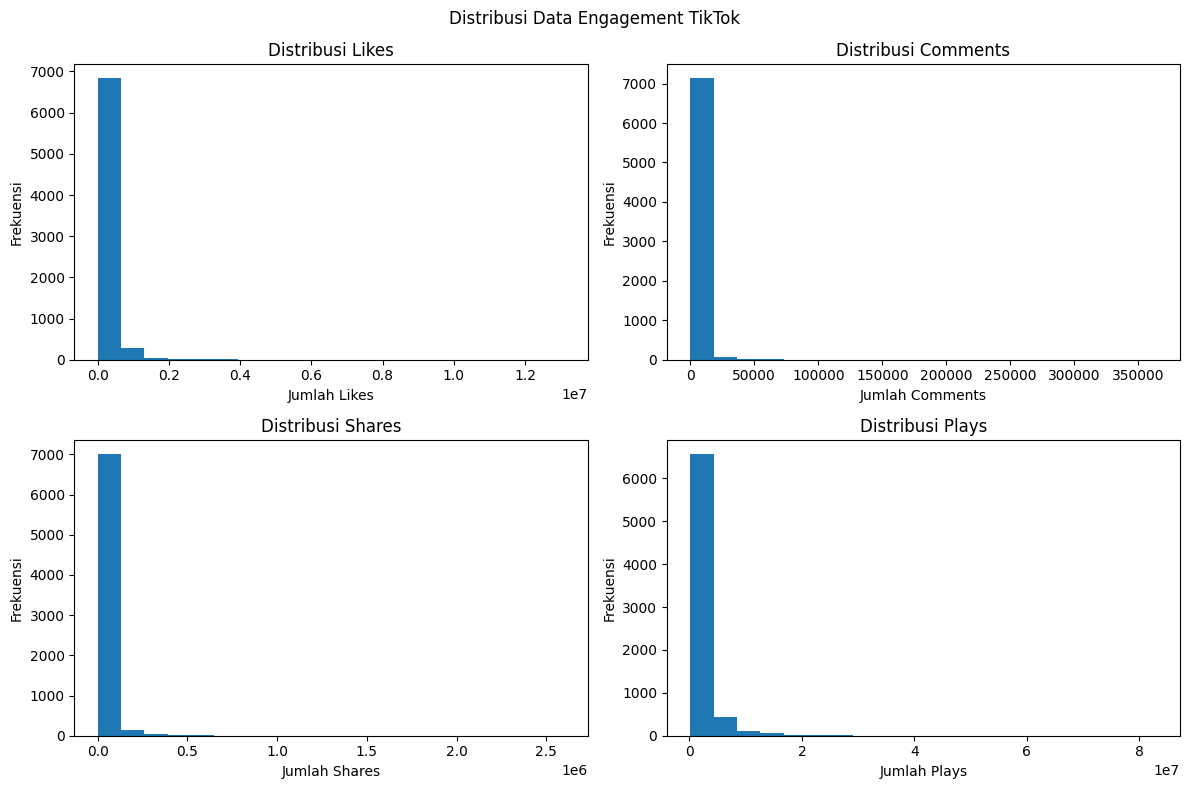

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].hist(df['likes'], bins=20)
axes[0,0].set_title('Distribusi Likes')
axes[0,0].set_xlabel('Jumlah Likes')
axes[0,0].set_ylabel('Frekuensi')

axes[0,1].hist(df['comments'], bins=20)
axes[0,1].set_title('Distribusi Comments')
axes[0,1].set_xlabel('Jumlah Comments')
axes[0,1].set_ylabel('Frekuensi')

axes[1,0].hist(df['shares'], bins=20)
axes[1,0].set_title('Distribusi Shares')
axes[1,0].set_xlabel('Jumlah Shares')
axes[1,0].set_ylabel('Frekuensi')

axes[1,1].hist(df['plays'], bins=20)
axes[1,1].set_title('Distribusi Plays')
axes[1,1].set_xlabel('Jumlah Plays')
axes[1,1].set_ylabel('Frekuensi')

plt.suptitle("Distribusi Data Engagement TikTok")
plt.tight_layout()
plt.show()

## **Step 3: Data Preprocessing**

### **Memilih Fitur Yang Digunakan**

In [ ]:
df = df[['likes', 'comments', 'shares', 'plays']]
df.head()

,likes,comments,shares,plays
0,44800,125,1863,686000.0
1,285700,290,963,1200000.0
2,38000,65,496,416100.0
3,87200,259,23600,725800.0
4,77600,724,1196,362100.0


### **Penanganan Missing Value dan Data Duplikat**

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

### **Mengecek Ada atau Tidaknya NaN**

In [ ]:
print(pd.DataFrame(X_train).isnull().sum())

0    0
1    0
2    0
3    0
dtype: int64


### **Menentukan Label Viralitas**

In [ ]:
threshold = df['plays'].quantile(0.75)

df['viral_label'] = df['plays'].apply(
    lambda x: 'Viral' if x >= threshold else 'Tidak Viral'
)

### **Memisahkan Fitur dan Label**

In [ ]:
features = ['likes', 'comments', 'shares', 'plays']

X = df[features]
y = df['viral_label']

df.head(10)

,likes,comments,shares,plays,viral_label
0,44800,125,1863,686000.0,Tidak Viral
1,285700,290,963,1200000.0,Tidak Viral
2,38000,65,496,416100.0,Tidak Viral
3,87200,259,23600,725800.0,Tidak Viral
4,77600,724,1196,362100.0,Tidak Viral
5,30200,32,1096,303200.0,Tidak Viral
6,782100,1267,88300,5100000.0,Viral
7,38900,196,3441,254600.0,Tidak Viral
15,91800,1985,907,780200.0,Tidak Viral
16,87800,1821,1047,1700000.0,Tidak Viral


### **Mengecek Distribusi Label**

In [ ]:
print(df['viral_label'].value_counts())

viral_label
Tidak Viral    5337
Viral          1881
Name: count, dtype: int64


### **Visualisasi Distribusi Label**

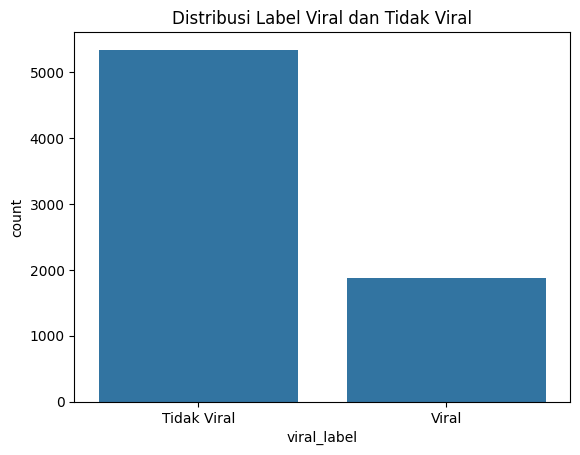

In [ ]:
sns.countplot(x='viral_label', data=df)

plt.title("Distribusi Label Viral dan Tidak Viral")
plt.show()

### **Encoding Label**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

print(y)

[0 0 0 ... 1 0 0]


### **Normalisasi Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Step 4: Data Balancing**

### **Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

### **Penerapan Metode SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

### **Menganalisis Imbalance Class**

In [ ]:
from collections import Counter

print(Counter(y_train_smote))

Counter({np.int64(0): 4269, np.int64(1): 4269})


## **Step 5: Exploratory Data Analysis**

### **Distribusi Engagement**

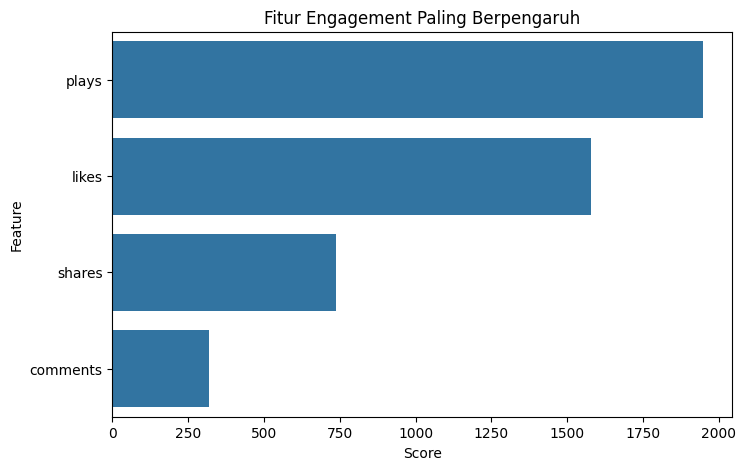

Skor Feature Selection:
    Feature        Score
3     plays  1947.203339
0     likes  1580.226856
2    shares   738.025250
1  comments   317.733832


In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Score',
    y='Feature',
    data=scores
)

plt.title("Fitur Engagement Paling Berpengaruh")
plt.show()
print("Skor Feature Selection:")
print(scores)

### **Correlation Heatmap**

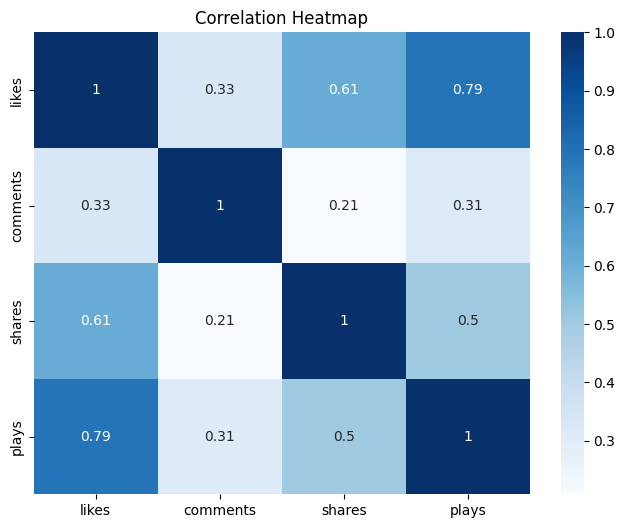

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['likes', 'comments', 'shares', 'plays']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

### **Menganalisis Data Viral vs Non-viral**

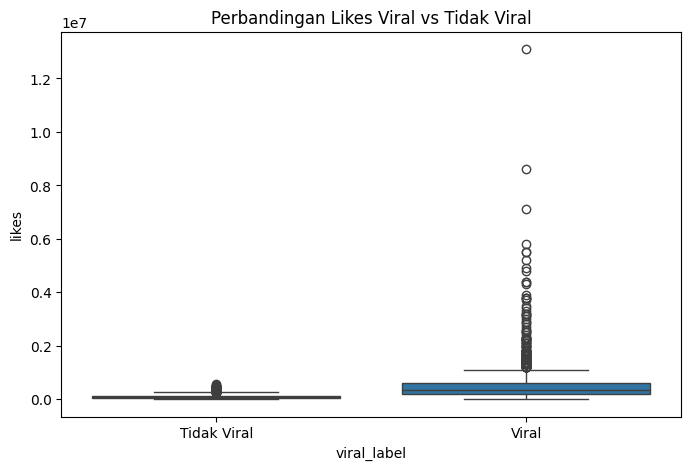

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='viral_label',
    y='likes',
    data=df
)

plt.title("Perbandingan Likes Viral vs Tidak Viral")
plt.show()

### **Visualisasi Likes, Comments, Shares, Plays**

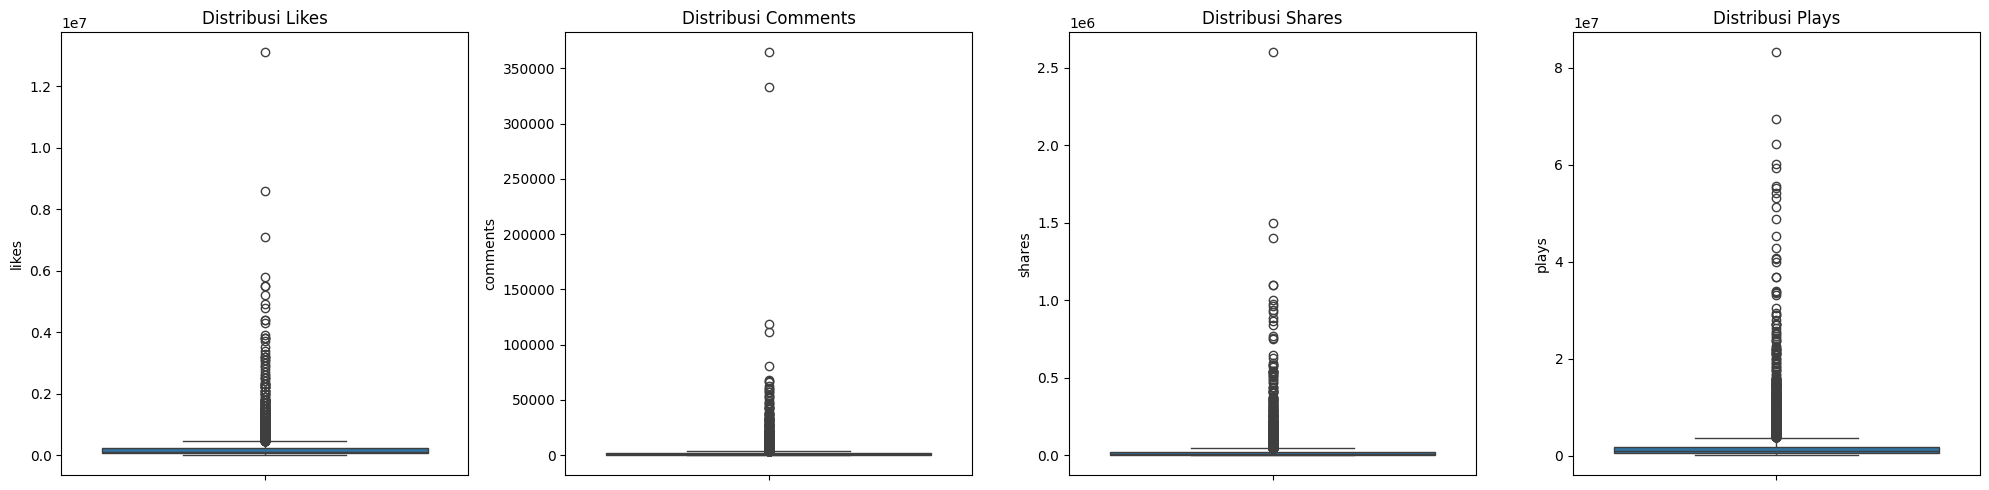

In [ ]:
plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
sns.boxplot(y=df['likes'])
plt.title('Distribusi Likes')

plt.subplot(1,4,2)
sns.boxplot(y=df['comments'])
plt.title('Distribusi Comments')

plt.subplot(1,4,3)
sns.boxplot(y=df['shares'])
plt.title('Distribusi Shares')

plt.subplot(1,4,4)
sns.boxplot(y=df['plays'])
plt.title('Distribusi Plays')

plt.tight_layout()
plt.show()

## **Step 6: Feature Selection**

### **Perhitungan Skor Fitur**

In [ ]:
score_values, p_values = f_classif(
    X_train_smote,
    y_train_smote
)

scores = pd.DataFrame({
    'Feature': features,
    'Score': score_values
})

scores = scores.sort_values(
    by='Score',
    ascending=False
)

print(scores)

    Feature        Score
3     plays  1947.203339
0     likes  1580.226856
2    shares   738.025250
1  comments   317.733832


## **Step 7: Data Splitting dan Step 8: Model Development**

### **Model SVM**

#### **Training Model SVM**

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf', C=1.0, gamma='scale', random_state=42
)

svm_model.fit(
    X_train_selected,
    y_train_smote
)

SVC(random_state=42)

#### **Prediksi Model SVM**

In [ ]:
y_pred_svm = svm_model.predict(X_test_selected)

### **Model MLP**

#### **Training Model MLP**

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64), activation='relu', max_iter=500, random_state=42
)

mlp_model.fit(
    X_train_selected,
    y_train_smote
)

MLPClassifier(hidden_layer_sizes=64, max_iter=500, random_state=42)

#### **Prediksi Model MLP**

In [ ]:
y_pred_mlp = mlp_model.predict(X_test_selected)

## **Step 9: Model Evaluation**

### **Evaluasi SVM**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1-Score:",
      f1_score(y_test, y_pred_svm))

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred_svm
))

Accuracy: 0.9792243767313019
Precision: 0.9261083743842364
Recall: 1.0
F1-Score: 0.9616368286445013

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1068
           1       0.93      1.00      0.96       376

    accuracy                           0.98      1444
   macro avg       0.96      0.99      0.97      1444
weighted avg       0.98      0.98      0.98      1444



### **Confusion Matrix SVM**

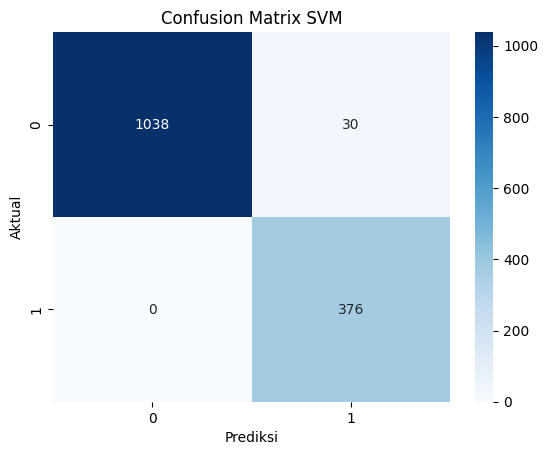

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.show()

### **Evaluasi MLP**

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

print("Precision:",
      precision_score(y_test, y_pred_mlp))

print("Recall:",
      recall_score(y_test, y_pred_mlp))

print("F1-Score:",
      f1_score(y_test, y_pred_mlp))

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred_mlp
))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1068
           1       1.00      1.00      1.00       376

    accuracy                           1.00      1444
   macro avg       1.00      1.00      1.00      1444
weighted avg       1.00      1.00      1.00      1444



### **Confusion Matrix MLP**

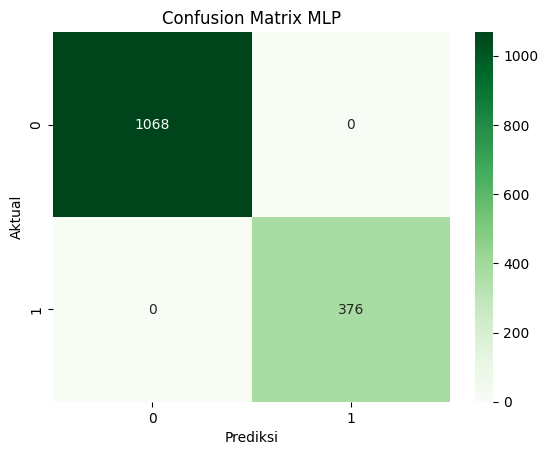

In [ ]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix MLP")

plt.show()

## **Step 10: Result Analysis**

### **Perbandingan Model**

In [ ]:
comparison = pd.DataFrame({
    'Model': ['SVM', 'MLP'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_mlp)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_mlp)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_mlp)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_mlp)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.979224,0.926108,1.0,0.961637
1,MLP,1.000000,1.000000,1.0,1.000000
